In [1]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow
from IPython.display import display, Javascript
from google.colab.output import eval_js
import base64

In [2]:
# Load face cascade
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

<IPython.core.display.Javascript object>

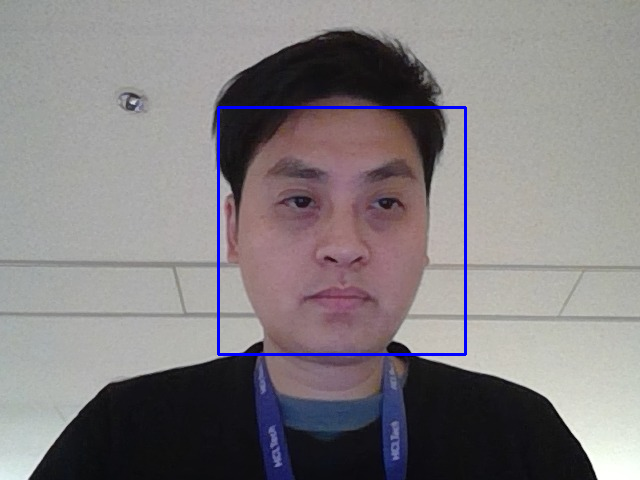

In [4]:
# Function to capture image from webcam
def take_photo():
    js = Javascript('''
        async function takePhoto() {
            const div = document.createElement('div');
            const capture = document.createElement('button');
            capture.textContent = 'Capture';
            div.appendChild(capture);

            const video = document.createElement('video');
            video.style.display = 'block';
            const stream = await navigator.mediaDevices.getUserMedia({video: true});

            document.body.appendChild(div);
            div.appendChild(video);
            video.srcObject = stream;
            await video.play();

            await new Promise((resolve) => capture.onclick = resolve);

            const canvas = document.createElement('canvas');
            canvas.width = video.videoWidth;
            canvas.height = video.videoHeight;
            canvas.getContext('2d').drawImage(video, 0, 0);

            stream.getTracks().forEach(track => track.stop());
            div.remove();

            return canvas.toDataURL('image/jpeg');
        }
    ''')
    display(js)
    data = eval_js('takePhoto()')
    binary = base64.b64decode(data.split(',')[1])
    return binary

# Capture image
image_bytes = take_photo()

# Convert to OpenCV format
np_arr = np.frombuffer(image_bytes, np.uint8)
frame = cv2.imdecode(np_arr, cv2.IMREAD_COLOR)

# Convert to grayscale
gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

# Detect faces
faces = face_cascade.detectMultiScale(gray, 1.1, 4)

# Draw rectangles
for (x, y, w, h) in faces:
    cv2.rectangle(frame, (x, y), (x+w, y+h), (255, 0, 0), 2)

# Show result
cv2_imshow(frame)

＃　https://universe.roboflow.com/


# Photo to catch your face.

In [5]:
!pip install keras-facenet streamlit pyngrok pandas matplotlib

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 55.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 113.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 76.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 63.1 MB/s eta 0:00:00
  Created wheel for keras-facenet: filename=keras_facenet-0.3.2-py3-none-any.whl size=10367 sha256=47656d58cb4413d130a81d843fdef01672745c02b9ee4c73eaa4e48ec2845726
  Stored in directory: /root/.cache/pip/wheels/05/b0/f5/19ac49fedc10b1df3ee56b096edbcfa39d45794fccc6bcdbbf
Successfully built keras-facenet


In [6]:
import cv2, os, base64
import numpy as np
from google.colab.output import eval_js
from IPython.display import Javascript, display

dataset_path = "dataset"
os.makedirs(dataset_path, exist_ok=True)

person_name = input("Enter Name: ")
person_path = os.path.join(dataset_path, person_name)
os.makedirs(person_path, exist_ok=True)

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

def capture_image():
    js = Javascript('''
    async function capture() {
        const video = document.createElement('video');
        const stream = await navigator.mediaDevices.getUserMedia({video:true});
        video.srcObject = stream;
        await video.play();

        const canvas = document.createElement('canvas');
        canvas.width = video.videoWidth;
        canvas.height = video.videoHeight;
        canvas.getContext('2d').drawImage(video, 0, 0);

        stream.getTracks().forEach(track => track.stop());
        return canvas.toDataURL('image/jpeg');
    }
    capture();
    ''')
    display(js)
    data = eval_js('capture()')
    binary = base64.b64decode(data.split(',')[1])
    np_arr = np.frombuffer(binary, np.uint8)
    return cv2.imdecode(np_arr, cv2.IMREAD_COLOR)

count = 0

for i in range(20):
    frame = capture_image()
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.3, 5)

    for (x,y,w,h) in faces:
        face = frame[y:y+h, x:x+w]
        face = cv2.resize(face, (160,160))
        cv2.imwrite(f"{person_path}/{count}.jpg", face)
        count += 1

print("Dataset created!")

Enter Name: yang


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Dataset created!


In [7]:
from keras_facenet import FaceNet
import pickle

embedder = FaceNet()

embeddings = []
labels = []

for person in os.listdir("dataset"):
    for img_name in os.listdir(f"dataset/{person}"):
        img_path = f"dataset/{person}/{img_name}"
        img = cv2.imread(img_path)

        img = cv2.resize(img, (160,160))
        img = np.expand_dims(img, axis=0)

        emb = embedder.embeddings(img)[0]

        embeddings.append(emb)
        labels.append(person)

# Save
data = {"embeddings": embeddings, "labels": labels}

with open("face_embeddings.pkl", "wb") as f:
    pickle.dump(data, f)

print("Embeddings saved!")

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
Embeddings saved!


In [8]:
import pandas as pd
from datetime import datetime
from sklearn.metrics.pairwise import cosine_similarity
import pickle

# Load embeddings
with open("face_embeddings.pkl", "rb") as f:
    data = pickle.load(f)

known_embeddings = data["embeddings"]
known_labels = data["labels"]

attendance_file = "attendance.csv"

if not os.path.exists(attendance_file):
    pd.DataFrame(columns=["Name","Time"]).to_csv(attendance_file, index=False)

def mark_attendance(name):
    df = pd.read_csv(attendance_file)
    if name not in df["Name"].values:
        df.loc[len(df)] = [name, datetime.now().strftime("%H:%M:%S")]
        df.to_csv(attendance_file, index=False)

# Capture
frame = capture_image()
face = cv2.resize(frame, (160,160))
face = np.expand_dims(face, axis=0)

test_emb = embedder.embeddings(face)[0]

# Compare
similarities = cosine_similarity([test_emb], known_embeddings)[0]
best_match = np.argmax(similarities)

if similarities[best_match] > 0.6:
    name = known_labels[best_match]
    print("Recognized:", name)
    mark_attendance(name)
else:
    print("Unknown")

<IPython.core.display.Javascript object>

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step
Recognized: yang
